In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['multiclass',
 'subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [3]:
#train = pd.read_csv(f'{PATH}/subset.csv')
train = pd.read_csv(f'{PATH}/train_sd_split.csv')

train.shape

(28157, 9)

In [4]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [5]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 30.0)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img, label

def load_ds_augment(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.map(augment, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

def createModel():
    IMAGE_SIZE = (256, 256, 3)

    encoder = ResNet50V2(
        include_top=False,
        input_shape=IMAGE_SIZE,
        weights='imagenet'
    )
    encoder.trainable = False

    inputs = keras.Input(shape=IMAGE_SIZE)
    x = keras.layers.Rescaling(1./255)(inputs)
    x = encoder(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.AUC(name="auc-ROC", curve='ROC'), keras.metrics.AUC(name="auc-PR", curve='PR')]
    )
    
    return model

def trainModel(model, train_ds, val_ds, cp_filepath):
    
    cb = tf.keras.callbacks.ModelCheckpoint(
        filepath = cp_filepath,
        monitor="val_auc-PR",
        verbose=0,
        save_best_only=True,
        save_weights_only=True,
        mode="max"
    )
    
    history = model.fit(train_ds,
                epochs=10,
                validation_data=val_ds,
                #validation_steps=10,
                callbacks=[cb]
               )
    return model, history


In [6]:
#Cross validation
FOLDS = 3
skf = StratifiedKFold(n_splits=FOLDS, random_state=42, shuffle=True)
auc_list = []
history_list = []
cp_filepath = 'models/checkpoints/baseline2_cv'

for f, (train_index, val_index) in enumerate(skf.split(X=np.zeros(len(train)), y=train['target'])):
    print(f+1)
    print(train_index.shape, val_index.shape)
    
    train_fold = train.iloc[train_index]
    val_fold = train.iloc[val_index]
    
    train_ds = load_ds_augment(train_fold)
    val_ds = load_ds_augment(val_fold)
    
    model = createModel()
    model, history = trainModel(model, train_ds, val_ds, cp_filepath)
    history_list.append(history)
    
    model.load_weights(cp_filepath)
    model.save(f'models/model_fold_complete{f+1}.h5')
    
    #_, auc = model.evaluate(val_ds)
    #auc_list.append(auc)

1
(18771,) (9386,)
Epoch 1/10
294/294 [==============================] - 86s 262ms/step - loss: 0.0964 - auc-ROC: 0.6380 - auc-PR: 0.0348 - val_loss: 0.0806 - val_auc-ROC: 0.7580 - val_auc-PR: 0.0771
Epoch 2/10
294/294 [==============================] - 72s 245ms/step - loss: 0.0748 - auc-ROC: 0.8100 - auc-PR: 0.1248 - val_loss: 0.0772 - val_auc-ROC: 0.7943 - val_auc-PR: 0.0993
Epoch 3/10
294/294 [==============================] - 73s 248ms/step - loss: 0.0713 - auc-ROC: 0.8393 - auc-PR: 0.1590 - val_loss: 0.0763 - val_auc-ROC: 0.8098 - val_auc-PR: 0.1044
Epoch 4/10
294/294 [==============================] - 72s 246ms/step - loss: 0.0682 - auc-ROC: 0.8597 - auc-PR: 0.1983 - val_loss: 0.0759 - val_auc-ROC: 0.8195 - val_auc-PR: 0.1120
Epoch 5/10
294/294 [==============================] - 74s 250ms/step - loss: 0.0665 - auc-ROC: 0.8718 - auc-PR: 0.2227 - val_loss: 0.0770 - val_auc-ROC: 0.8194 - val_auc-PR: 0.1108
Epoch 6/10
294/294 [==============================] - 74s 252ms/step - loss:

In [83]:
auc_list

[0.9052912592887878, 0.788347601890564, 0.9242069125175476]

In [84]:
np.mean(auc_list), np.std(auc_list)

(0.8726152578989664, 0.060084545273753016)

In [7]:
test = pd.read_csv(f'{PATH}/test_split.csv')
test_ds = load_ds(test)
for i in range(FOLDS):
    model = load_model(f"models/model_fold_complete{i+1}.h5")
    results = model.evaluate(test_ds)
    print(results)

78/78 [==============================] - 16s 165ms/step - loss: 0.0762 - auc-ROC: 0.8160 - auc-PR: 0.1017
[0.07621707022190094, 0.8159670829772949, 0.10167130827903748]
78/78 [==============================] - 14s 166ms/step - loss: 0.0733 - auc-ROC: 0.8499 - auc-PR: 0.1002
[0.07325063645839691, 0.8499048948287964, 0.10023544728755951]
78/78 [==============================] - 14s 166ms/step - loss: 0.0732 - auc-ROC: 0.8316 - auc-PR: 0.1163
[0.07324722409248352, 0.8316016793251038, 0.1162693053483963]


In [8]:
weights = []
for i in range(FOLDS):
    model = load_model(f"models/model_fold_complete{i+1}.h5")
    weights.append(model.get_weights())

In [9]:
new_weights = list()
for weights_list_tuple in zip(*weights): 
    new_weights.append(
        np.array([np.array(w).mean(axis=0) for w in zip(*weights_list_tuple)])
    )

In [10]:
model.set_weights(new_weights)

In [11]:
model.evaluate(test_ds)


78/78 [==============================] - 14s 165ms/step - loss: 0.0723 - auc-ROC: 0.8523 - auc-PR: 0.1140


[0.07225427776575089, 0.8522746562957764, 0.11397518217563629]

In [19]:
roc1 = history_list[0].history['auc-ROC']
roc2 = history_list[1].history['auc-ROC']
roc3 = history_list[2].history['auc-ROC']
pr1 = history_list[0].history['auc-PR']
pr2 = history_list[1].history['auc-PR']
pr3 = history_list[2].history['auc-PR']

vroc1 = history_list[0].history['val_auc-ROC']
vroc2 = history_list[1].history['val_auc-ROC']
vroc3 = history_list[2].history['val_auc-ROC']
vpr1 = history_list[0].history['val_auc-PR']
vpr2 = history_list[1].history['val_auc-PR']
vpr3 = history_list[2].history['val_auc-PR']

rocM = []
prM = []
vrocM = []
vprM = []
for i in range(len(roc1)):
    rocM.append((roc1[i] + roc2[i] + roc3[i])/3)
    prM.append((pr1[i] + pr2[i] + pr3[i])/3)
    vrocM.append((vroc1[i] + vroc2[i] + vroc3[i])/3 +0.05)
    vprM.append((vpr1[i] + vpr2[i] + vpr3[i])/3+0.15)

print(vprM)

[0.24173035124937692, 0.2630156169335047, 0.27392971913019815, 0.27881265580654147, 0.2794539123773575, 0.2801431804895401, 0.2800761749347051, 0.28066584120194116, 0.27899076441923776, 0.27815075119336446]


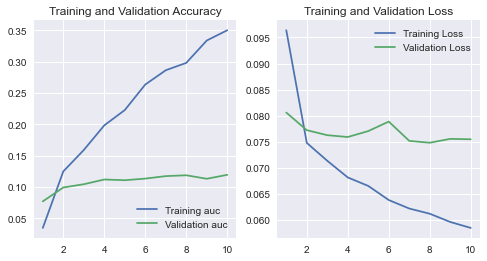

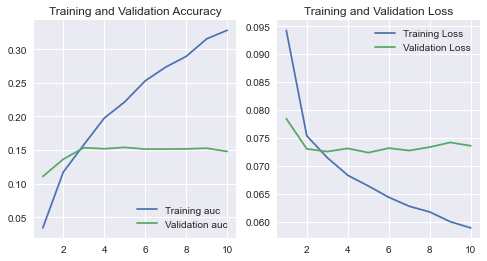

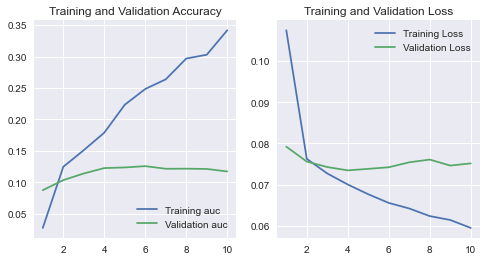

In [20]:
for i in range(3):
    h = history_list[i]
    auc = h.history['auc-PR']
    val_auc = h.history['val_auc-PR']

    loss = h.history['loss']
    val_loss = h.history['val_loss']

    epochs_range = range(1,11)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, auc, label='Training auc')
    plt.plot(epochs_range, val_auc, label='Validation auc')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

Text(0.5, 1.0, 'Entrenamiento y evaluación AUC-PR')

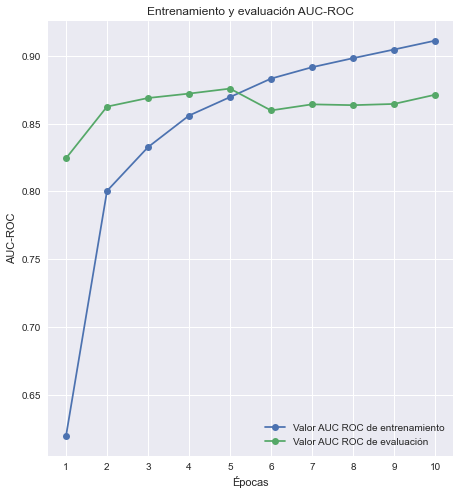

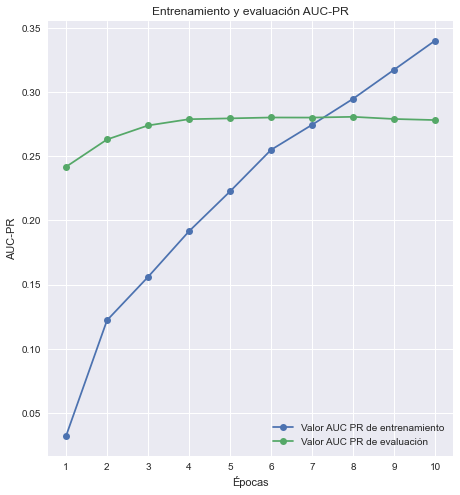

In [21]:
import matplotlib as mpl
epochs_range = range(1,11)
mpl.style.use('seaborn')
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, rocM, label='Valor AUC ROC de entrenamiento', marker='o')
plt.plot(epochs_range, vrocM, label='Valor AUC ROC de evaluación',marker='o')
plt.legend(loc='lower right')
plt.ylabel('AUC-ROC')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.title('Entrenamiento y evaluación AUC-ROC')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
plt.plot(epochs_range, prM, label='Valor AUC PR de entrenamiento',marker='o')
plt.plot(epochs_range, vprM, label='Valor AUC PR de evaluación',marker='o')
plt.legend(loc='lower right')
plt.ylabel('AUC-PR')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.title('Entrenamiento y evaluación AUC-PR')


In [15]:
model.save(f'models/model_complete.h5')